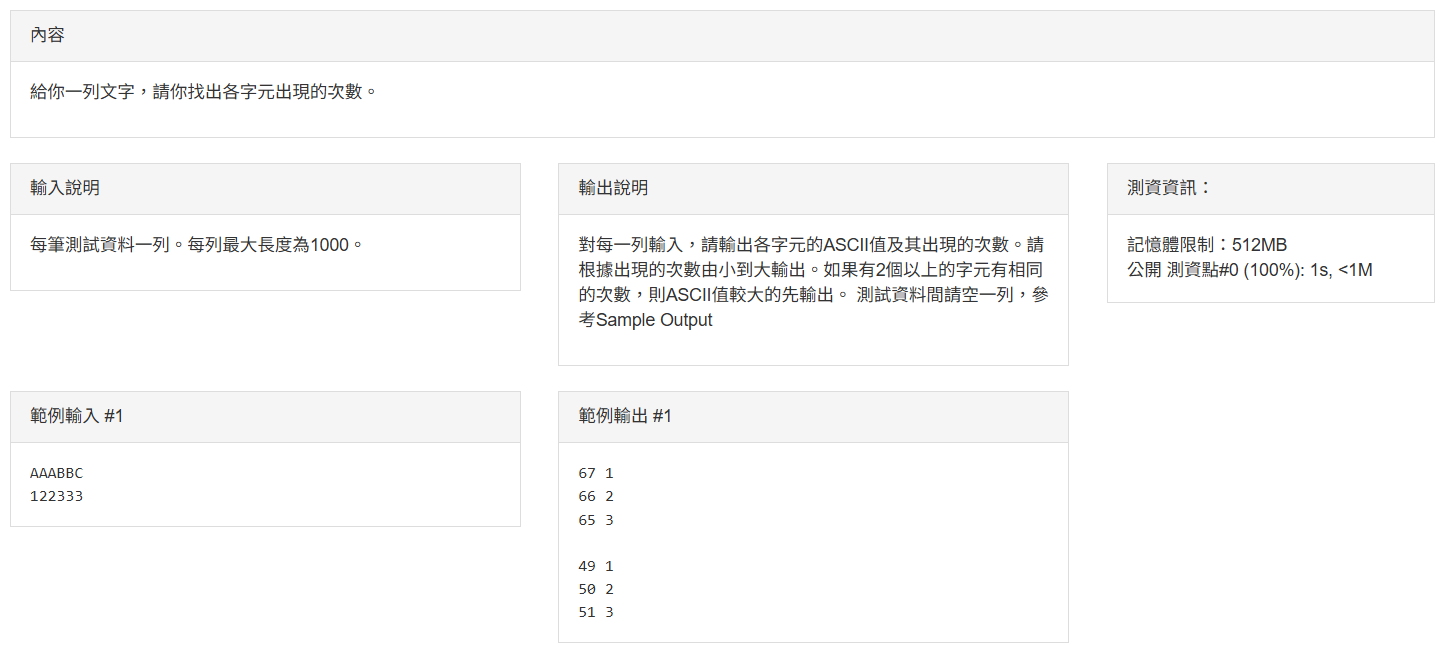

In [ ]:
### 自寫 ###

import sys

data = sys.stdin.readlines() #type list with str
input_length = len(data)
lines = []
for line in data:
	lines.append(line.rstrip("\n"))

for i in range(0, input_length): #i is index
	
	strlines = []
	for j in lines[i]:
		strlines.append(j)
	
	tuples = [] #store the tuples with strs and its frequencies
	for k in set(strlines):
		time = strlines.count(k) #計次寫法
		tuples.append((time, k))
	
	tuples = sorted(tuples, key = lambda x :(x[0], -ord(x[1])))
	for l in tuples:
		print(ord(l[1]),l[0])
		
	if i != input_length - 1:
		print("")

In [ ]:
### 原思路精修版 ###

import sys

lines = sys.stdin.read().splitlines() #全讀搭配slpitlines，更為精簡
input_length = len(lines)

for i, line in enumerate(lines): #i 是 index
    frequency_data = []

    for character in set(line): #set可以直接對字串使用，且會直接逐字元處理，不一定要list轉set
        frequency = line.count(character)
        frequency_data.append((frequency, character))

    frequency_data.sort(key=lambda item: (item[0], -ord(item[1])))

    for frequency, character in frequency_data:
        print(ord(character), frequency)

    if i != input_length - 1:
        print()

In [ ]:
### GPT版本 ###
import sys
from collections import Counter

lines = sys.stdin.read().splitlines()

for line_index, line in enumerate(lines):
    
    frequencies = Counter(line)

    result = [(ord(character), frequency) for character, frequency in frequencies.items()]

    result.sort(key=lambda item: (item[1], -item[0]))

    for ascii_code, frequency in result:
        print(ascii_code, frequency)

    if line_index != len(lines) - 1:
        print()

### Note:
1. - input(): 回傳 str。
    - sys.stdin.read(): 讀全部，回傳 str。
    - sys.stdin.readline(): 讀一行，回傳 str，常搭配for迴圈。
    - sys.stdin.readlines(): 讀全部行，回傳 list["str"]，存每一行的標準輸入。
2. - split(): 切割字串
    - splitlines(): 切割行
    - strip(): 去除前後空白
    - rstrip(): 去除最後面的空白，r指right。
3. range(start, stop, step): 注意會包含start，但不含stop。
4. 要會.count()基本計次寫法。
5. sorted(iterable, key=None, reverse=False): 
    - iterable: 要排序的資料，例如 list、tuple、set。
    - key: 指定「根據什麼值排序」，用來接收一個排序的函數。
    - reverse: 是否把整個排序結果反轉。
    - 預設由小排到大。
    - 詳細範例與觀念見下方筆記。
6. 假設一個tuple: x(5, 4)，那要取出 5, 4，分別就要用x[0], x[1]來表示，其中 0, 1 是 tuple 中的 index。
7. ord(字元)可以顯示其unicode編碼，而ASCII的編碼又包含在Unicode裡面，因此符合；chr(編碼)可以將ASCII編碼轉為字元。
8. enumerate 觀念比較:(詳見以下筆記)
    - tuple：用來存放一組固定順序資料的容器型態。
    - enumerate()：建立一個迭代器，自動替原資料加上索引。
    - enumerate 每次迭代產生一個 (索引, 元素) tuple。
    - for index, element 再把這個 tuple 解包。
9. for ascii_code, frequency in result: 兩個參數可以將tuple解包。
10. Counter(lines)會將lines內的所有字元作計算，回傳的型態舉為Counter({字元: 出現數})，例如Counter({'A': 3, 'B': 1, ' ': 1})，類似字典型態，frequencies["A"]則會回傳值1。
11. .items()會取得所有key與value，形成(鍵, 值)的tuple。

### 關於enumerate的使用:

| 型態          | 範例                   | 每次取出的內容               |
| ----------- | -------------------- | ---------------------- |
| 字串 `str`    | `"123"`              | 一個字元：`"1"`、`"2"`、`"3"` |
| 串列 `list`   | `[10, 20, 30]`       | 一個元素：`10`、`20`、`30`    |
| 元組 `tuple`  | `(10, 20, 30)`       | 一個元素：`10`、`20`、`30`    |
| 範圍 `range`  | `range(3)`           | `0`、`1`、`2`                |
| 集合 `set`    | `{10, 20, 30}`       | 每個元素，但順序不保證         |
| 字典 `dict`   | `{"a": 10, "b": 20}` | 預設取出鍵 `key`              |
| 位元組 `bytes` | `b"ABC"`             | 每個位元組對應的整數          |
| 檔案物件        | `open(...)`          | 每次取出一整行               |

小比較:

| 寫法                                  | 每次取得的內容                      |
| ---------------------------------     | --------------------------------   |
| `for i in number:`                    | `"5"`、`"7"`、`"2"`                |
| `for digit in number:`                | `"5"`、`"7"`、`"2"`                |
| `for i in enumerate(number):`         | `(0, "5")`、`(1, "7")`、`(2, "2")` |
| `for digit in enumerate(number):`     | `(0, "5")`、`(1, "7")`、`(2, "2")` |
| `for i, digit in enumerate(number):`  |i = 0，digit = "5" /i = 1，digit = "7"/ i = 2，digit = "2"|

- enumerate 會先將number形成一個tuple的迭代物件，而這個tuple會包含一個索引與對應的number的元素。
- 如果只有一個變數i或只有digit在接收enumerate，則會收到tuple，因為該tuple沒有解包。
- 若同時有兩個變數去接收，則enumerate形成的tuple，會解包，將索引、字串對應出來。


In [ ]:
### sort用法範例筆記 ###

## 程式碼
words = ["apple", "cat", "banana", "dog"]

def get_length(word):
    return len(word)

result = sorted(words, key=get_length)

## 意同於將word的內容都作了以下處理:
get_length("apple")   # 5
get_length("cat")     # 3
get_length("banana")  # 6
get_length("dog")     # 3

## 結果來說會得到:
["cat", "dog", "apple", "banana"]

## 該函式def get_length(word)也可用匿名函數lambda表達為:
lambda word: len(word) #型態: lambda 參數: 回傳值，特別注意word這個函數名稱可以任意取。

## 以此題來說明:
sorted(tuples, key = lambda x :(x[0], -ord(x[1]))) 
# x代表的是個匿名函數lambda的參數，而這個匿名函數就是將tuples(type: list with tuple)這個內容物丟進來，
# 因此x便代表著tuples裡面的tuple元素，所以後面的回傳值才會有x[0], x[1]來表達tuple內的值。
# (x[0], -ord(x[1]))代表先比較x[0]，再比較-ord(x[1])，兩者交換先後比較順序不同，但最後tuple內容物仍是相同，僅排序受影響。